<a href="https://colab.research.google.com/github/touhid0503/Machine-Learning-Full-Course-with-Scikit-Learn/blob/main/05_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression using Scikit-Learn

In [278]:
from sklearn.linear_model import LinearRegression

In [279]:
model=LinearRegression()

In [280]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianHQ/notebooks/refs/heads/main/machine-learning-with-python-zero-to-gbms/lesson-1-linear-regression-with-scikit-learn/medical-charges.csv'

In [281]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7cf335318f80>)

In [282]:
import pandas as pd

In [283]:
medical_df = pd.read_csv('medical.csv')

In [284]:
medical_df.sample(5)

,age,sex,bmi,children,smoker,region,charges
756,39,female,22.80,3,no,northeast,7985.81500
262,52,male,24.32,3,yes,northeast,24869.83680
930,26,male,46.53,1,no,southeast,2927.06470
1157,23,female,23.18,2,no,northwest,14426.07385
758,30,male,37.43,3,no,northeast,5428.72770


In [285]:
medical_df.shape

(1338, 7)

In [286]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [287]:
non_smoker_df.sample(5)

,age,sex,bmi,children,smoker,region,charges
1221,40,male,24.970,2,no,southeast,6593.50830
1279,25,female,26.790,2,no,northwest,4189.11310
17,23,male,23.845,0,no,northeast,2395.17155
490,19,female,32.900,0,no,southwest,1748.77400
931,39,female,32.500,1,no,southwest,6238.29800


In [288]:
non_smoker_df.shape

(1064, 7)

In [289]:
import numpy as np

In [290]:
def rmse(targets, predictions):
    return np.sqrt(np.mean((targets - predictions)**2))

In [291]:
import matplotlib.pyplot as plt

#Linear Regression using Multiple Features


In [292]:
inputs, targets = non_smoker_df[['age','bmi']], non_smoker_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


In [293]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

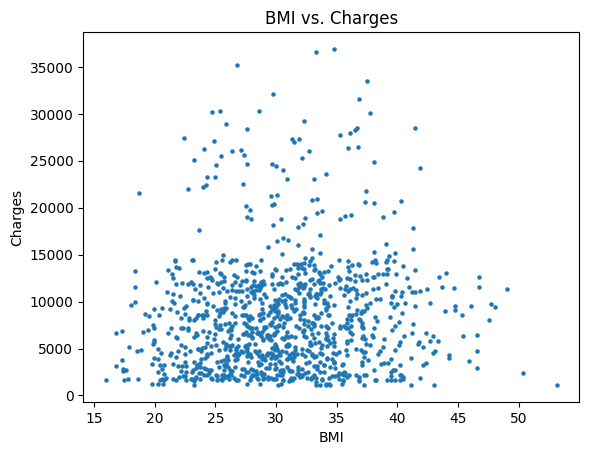

In [294]:
plt.scatter(non_smoker_df['bmi'], non_smoker_df['charges'], s=5)
plt.title('BMI vs. Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

In [295]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

In [296]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [297]:
import seaborn as sns

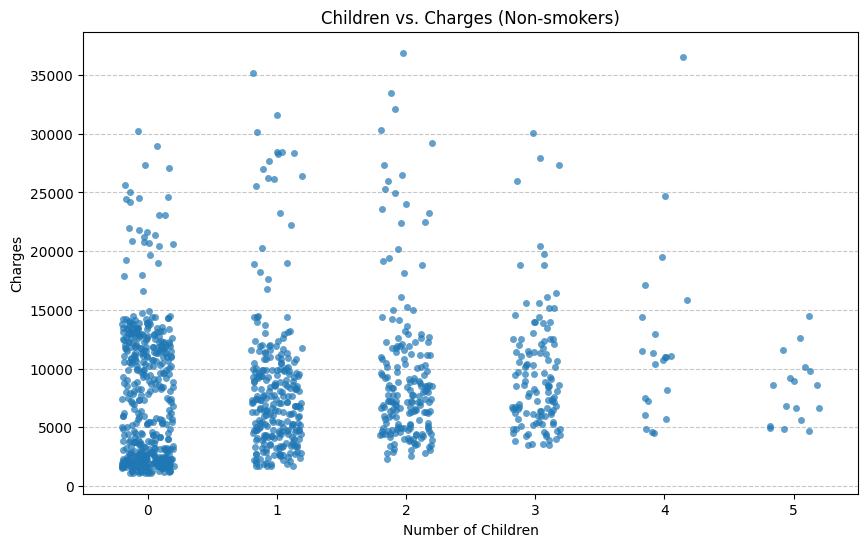

In [298]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='children', y='charges', data=non_smoker_df, jitter=0.2, alpha=0.7, s=5)
plt.title('Children vs. Charges (Non-smokers)')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [299]:
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


In [300]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [301]:
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


#Using Categorical Features for Machine Learning


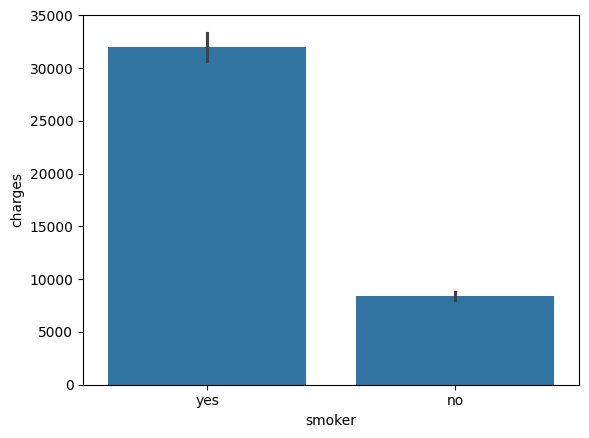

In [302]:
sns.barplot(data=medical_df, x='smoker', y='charges');

In [303]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [304]:
medical_df.sample(5)

,age,sex,bmi,children,smoker,region,charges,smoker_code
677,60,male,31.350,3,yes,northwest,46130.52650,1
1016,19,female,24.605,1,no,northwest,2709.24395,0
753,58,female,22.770,0,no,southeast,11833.78230,0
495,20,male,27.930,0,no,northeast,1967.02270,0
483,51,female,39.500,1,no,southwest,9880.06800,0


In [305]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

In [306]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


<Axes: xlabel='sex', ylabel='charges'>

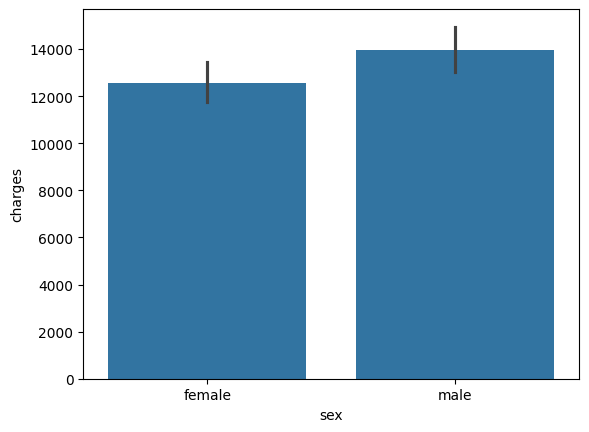

In [307]:
sns.barplot(data=medical_df, x='sex', y='charges')

In [308]:
sex_codes = {'female': 0, 'male': 1}
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [309]:
medical_df.sample(5)

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
227,58,female,41.91,0,no,southeast,24227.33724,0,0
1286,28,female,17.29,0,no,northeast,3732.62510,0,0
21,30,female,32.40,1,no,southwest,4149.73600,0,0
1285,47,female,24.32,0,no,northeast,8534.67180,0,0
866,18,male,37.29,0,no,southeast,1141.44510,0,1


In [310]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [311]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


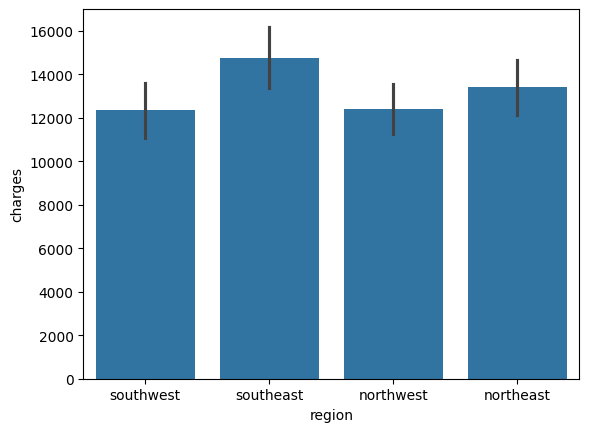

In [312]:
sns.barplot(data=medical_df, x='region', y='charges');

In [313]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()

In [314]:
one_hot = enc.fit_transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [315]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [316]:
one_hot.shape

(1338, 4)

In [317]:
medical_df.shape

(1338, 13)

In [318]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [319]:
medical_df.charges.corr(medical_df.northeast)

np.float64(0.006348771280156089)

In [320]:
medical_df.charges.corr(medical_df.northwest)

np.float64(-0.03990486404043802)

In [321]:
medical_df.charges.corr(medical_df.southeast)

np.float64(0.07398155156575982)

In [322]:
medical_df.charges.corr(medical_df.southwest)

np.float64(-0.04321002899168478)

#Model Improvements


In [323]:
model.coef_, model.intercept_

(array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
         -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
         -373.04175627]),
 np.float64(-12525.547811195444))

In [324]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [325]:
input_cols

['age',
 'bmi',
 'children',
 'smoker_code',
 'sex_code',
 'northeast',
 'northwest',
 'southeast',
 'southwest']

In [326]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df

,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


In [327]:
from sklearn.preprocessing import StandardScaler

In [328]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaled_inputs = scaler.fit_transform(medical_df[numeric_cols])

In [329]:
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [330]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [331]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [332]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [333]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values

In [334]:
categorical_data

array([[1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0.]])

In [335]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [336]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


In [337]:
from sklearn.model_selection import train_test_split

In [338]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

In [339]:
model = LinearRegression().fit(inputs_train, targets_train)

predictions_test = model.predict(inputs_test)

loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 5819.224690964316


In [340]:
predictions_train = model.predict(inputs_train)

loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 6068.354261892358
